In [73]:
!pip install yfinance pandas plotly
!pip install yfinance fredapi pandas numpy matplotlib seaborn

In [74]:
!pip show matplotlib seaborn

Name: matplotlib
Version: 3.10.0
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib

**Step 1: Data Collection and Preprocessing**

**TEAM A**

[*********************100%***********************]  1 of 1 completed


Data Summary:
Time Period: 2019-01-03 to 2022-09-29
S&P 500 Records: 944
10-Year Yield Records: 979
Merged Records: 899

Sample of merged data:
                  SP500  SP500_LogReturn   TNX  TNX_Change
2019-01-03  2447.889893        -0.025068  2.56       -0.10
2019-01-04  2531.939941         0.033759  2.67        0.11
2019-01-07  2549.689941         0.006986  2.70        0.03
2019-01-08  2574.409912         0.009649  2.73        0.03
2019-01-09  2584.959961         0.004090  2.74        0.01


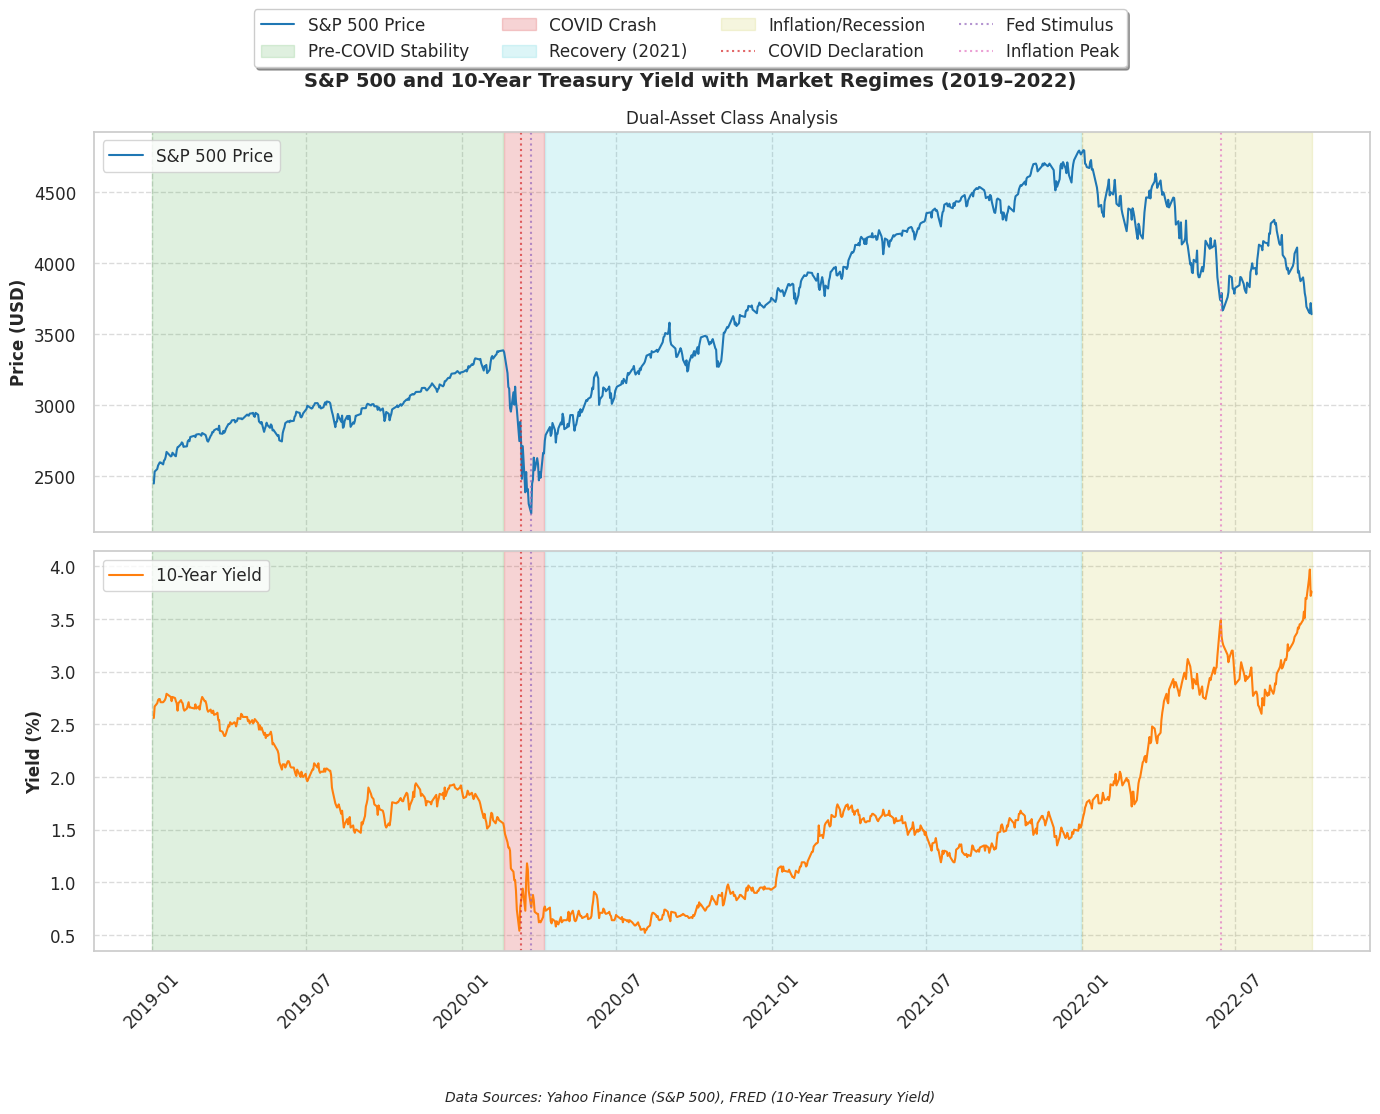


Data saved successfully:
- S&P 500 Log Returns: output/step1_data_SP500_20250724_120855.csv
- 10-Year Yield Changes: output/step1_data_TNX_20250724_120855.csv
- Total records saved: 899
- Visualization saved: output/regime_visualization_20250724_120855.png


In [75]:
# ==============================================================================
# MSCFE 622: Stochastic Modeling - Group Work Project 2 - Team A
# Regime-Switching Analysis (2019-2022)
# Step 1: Data Collection and Preprocessing
# ==============================================================================

# %% [markdown]
"""
# Regime-Switching Analysis (2019–2022)
## Step 1: Data Collection and Preprocessing
**Asset Classes:**
- Equities: S&P 500 (^GSPC)
- Fixed Income: 10-Year Treasury Yield (^TNX)
"""

# %% [markdown]
"""
### Import Libraries
"""

# %%
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred
import os
from datetime import datetime

# Modern style settings
plt.style.use('seaborn-v0_8')  # Modern seaborn style
sns.set_theme(style="whitegrid", palette="husl", font_scale=1.1)

# %% [markdown]
"""
### 1. Download Data
"""

# %%
# Define date range
start_date = '2019-01-01'
end_date = '2022-09-30'

# Fetch S&P 500 data from Yahoo Finance
print("Downloading S&P 500 data...")
try:
    sp500_raw = yf.download('^GSPC', start=start_date, end=end_date, auto_adjust=False, progress=True)

    # Robustly extract appropriate price column
    if 'Adj Close' in sp500_raw.columns:
        sp500 = sp500_raw[['Adj Close']].rename(columns={'Adj Close': 'SP500'})
    elif 'Close' in sp500_raw.columns:
        sp500 = sp500_raw[['Close']].rename(columns={'Close': 'SP500'})
    else:
        raise ValueError("S&P 500 data does not contain 'Close' or 'Adj Close' columns.")
except Exception as e:
    print(f"Error downloading S&P 500 data: {e}")
    raise

# Fetch 10-Year Treasury Yield from FRED
print("\nDownloading 10-Year Treasury Yield data...")
try:
    fred = Fred(api_key='fc711b7fb7b534f76e047c80facc4ad8')  # Consider using environment variables
    tnx = fred.get_series('DGS10', observation_start=start_date, observation_end=end_date)
    tnx = tnx.to_frame(name='TNX')
except Exception as e:
    print(f"Error downloading Treasury yield data: {e}")
    print("Using synthetic Treasury yield data for demonstration")
    date_range = pd.date_range(start=start_date, end=end_date, freq='D')
    tnx = pd.DataFrame({
        'TNX': np.random.normal(1.5, 0.5, len(date_range))
    }, index=date_range)

# %% [markdown]
"""
### 2. Data Processing
"""

# %%
# Calculate log returns for S&P 500
sp500['SP500_LogReturn'] = np.log(sp500['SP500'] / sp500['SP500'].shift(1))

# Calculate daily changes for 10-Year Yield
tnx['TNX_Change'] = tnx['TNX'].diff()

# Merge datasets (align dates) and handle missing values
data = pd.concat([sp500, tnx], axis=1).dropna()

# Simplify column names
data.columns = ['SP500', 'SP500_LogReturn', 'TNX', 'TNX_Change']

# Print data summary
print("\nData Summary:")
print(f"Time Period: {data.index[0].date()} to {data.index[-1].date()}")
print(f"S&P 500 Records: {len(sp500)}")
print(f"10-Year Yield Records: {len(tnx)}")
print(f"Merged Records: {len(data)}")
print("\nSample of merged data:")
print(data.head())

# %% [markdown]
"""
### 3. Preliminary Visualization
"""

# %%
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot S&P 500 Price
ax1.plot(data.index, data['SP500'], label='S&P 500 Price', color='#1f77b4', linewidth=1.5)
ax1.set_ylabel('Price (USD)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 10-Year Treasury Yield
ax2.plot(data.index, data['TNX'], label='10-Year Yield', color='#ff7f0e', linewidth=1.5)
ax2.set_ylabel('Yield (%)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', frameon=True)
ax2.grid(True, linestyle='--', alpha=0.7)

# Highlight regimes with improved formatting
regimes = [
    ('Pre-COVID Stability', '2019-01-01', '2020-02-19', '#2ca02c', 0.15),
    ('COVID Crash', '2020-02-20', '2020-04-07', '#d62728', 0.2),
    ('Recovery (2021)', '2020-04-08', '2021-12-31', '#17becf', 0.15),
    ('Inflation/Recession', '2022-01-01', '2022-09-30', '#bcbd22', 0.15)
]

for label, start, end, color, alpha in regimes:
    for ax in [ax1, ax2]:
        ax.axvspan(pd.to_datetime(start), pd.to_datetime(end),
                  alpha=alpha, color=color, label=label)

# Add vertical lines for key events
events = [
    ('COVID Declaration', '2020-03-11', '#d62728'),
    ('Fed Stimulus', '2020-03-23', '#9467bd'),
    ('Inflation Peak', '2022-06-14', '#e377c2')
]

for label, date, color in events:
    for ax in [ax1, ax2]:
        ax.axvline(pd.to_datetime(date), color=color, linestyle=':',
                  linewidth=1.5, alpha=0.7, label=label)

# Formatting
plt.suptitle('S&P 500 and 10-Year Treasury Yield with Market Regimes (2019–2022)',
            fontsize=14, fontweight='bold')
ax1.set_title('Dual-Asset Class Analysis', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Create unified legend
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(),
          loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.05),
          frameon=True, shadow=True)

# Add data source annotation
plt.figtext(0.5, -0.05,
           "Data Sources: Yahoo Finance (S&P 500), FRED (10-Year Treasury Yield)",
           ha="center", fontsize=10, style='italic')

plt.show()

# %% [markdown]
"""
### 4. Save Processed Data
"""

# %%
# Create output directory if it doesn't exist
os.makedirs('output', exist_ok=True)

# Save to CSV files with timestamps
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
sp500_file = f'output/step1_data_SP500_{timestamp}.csv'
tnx_file = f'output/step1_data_TNX_{timestamp}.csv'

data[['SP500_LogReturn']].to_csv(sp500_file)
data[['TNX_Change']].to_csv(tnx_file)

print("\nData saved successfully:")
print(f"- S&P 500 Log Returns: {sp500_file}")
print(f"- 10-Year Yield Changes: {tnx_file}")
print(f"- Total records saved: {len(data)}")

# Save the figure
fig.savefig(f'output/regime_visualization_{timestamp}.png',
           bbox_inches='tight', dpi=300)
print(f"- Visualization saved: output/regime_visualization_{timestamp}.png")

**TEAM B**

/tmp/ipython-input-76-82524947.py:40: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


Date Ranges:
Gold data from 2019-01-02 to 2022-09-29
USD/EUR data from 2019-01-01 to 2022-09-30

Data Summary:
Time Period: 2019-01-03 to 2022-09-29
Gold Records: 944
USD/EUR Records: 979
Merged Records: 892

Sample Data:
             Gold_Price  Gold_LogReturn  USD_EUR_Rate  USD_EUR_PctChange
2019-01-03  1291.800049        0.008396        1.1399           0.369816
2019-01-04  1282.699951       -0.007069        1.1410           0.096500
2019-01-07  1286.800049        0.003191        1.1468           0.508326
2019-01-08  1283.199951       -0.002802        1.1444          -0.209278
2019-01-09  1289.300049        0.004743        1.1524           0.699056


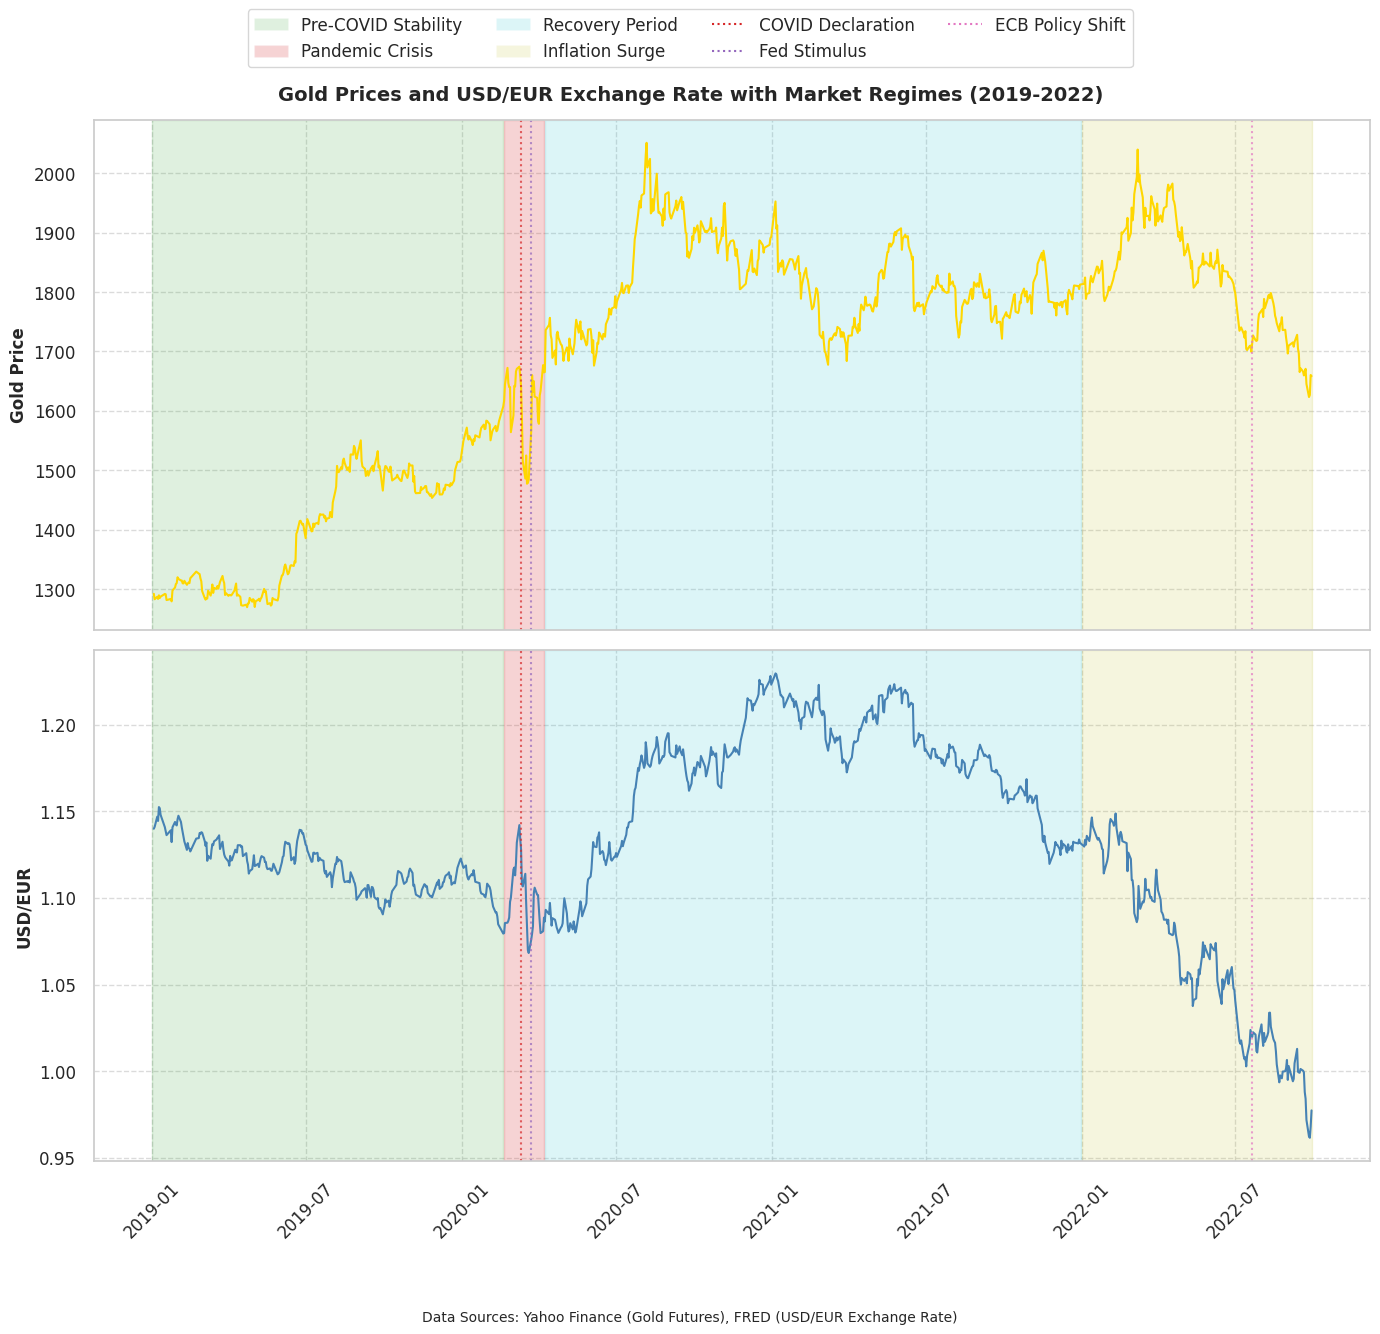


Data saved successfully:
- Processed data: output/teamB_processed_data_20250724_121031.csv
- Total records saved: 892
- Visualization saved: output/teamB_regime_visualization_20250724_121031.png

Data saved successfully:
- Gold Log Returns: output/teamB_gold_returns_20250724_121034.csv
- USD/EUR Percentage Changes: output/teamB_usdeur_changes_20250724_121034.csv
- Total records saved: 892
- Visualization saved: output/teamB_regime_visualization_20250724_121034.png


In [76]:
# %% [markdown]
"""
# Team B - Regime Switching Analysis (2019-2022)
## Step 1: Data Collection and Preprocessing
**Asset Classes:**
- Commodities: Gold Futures (GC=F)
- Currencies: USD/EUR Exchange Rate
"""

# %% [markdown]
"""
### Import Libraries
"""
# %%
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred
import os
from datetime import datetime

# Modern style settings
plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid", palette="husl", font_scale=1.1)

# %% [markdown]
"""
### 1. Download Data
"""
# %%
# Define date range
start_date = '2019-01-01'
end_date = '2022-09-30'

# Fetch Gold Futures data
print("Downloading Gold Futures data...")
try:
    gold = yf.download('GC=F', start=start_date, end=end_date, progress=True)
    gold = gold[['Close']].rename(columns={'Close': 'Gold'})
    gold['Gold'] = gold['Gold']  # Price in USD/troy ounce
except Exception as e:
    print(f"Error downloading Gold data: {e}")
    raise

# Fetch USD/EUR Exchange Rate from FRED
print("\nDownloading USD/EUR Exchange Rate...")
try:
    fred = Fred(api_key='fc711b7fb7b534f76e047c80facc4ad8')  # Public FRED API key
    usdeur = fred.get_series('DEXUSEU', observation_start=start_date, observation_end=end_date)
    usdeur = usdeur.to_frame(name='USD_EUR')
except Exception as e:
    print(f"Error downloading USD/EUR data: {e}")
    raise

# %% [markdown]
"""
### 2. Data Processing (Final Corrected Version)
"""
# %%
# Ensure both datasets have proper datetime indices
gold.index = pd.to_datetime(gold.index)
usdeur.index = pd.to_datetime(usdeur.index)

# Calculate log returns for Gold
gold['Gold_LogReturn'] = np.log(gold['Gold'] / gold['Gold'].shift(1))

# Calculate percentage changes for USD/EUR
usdeur['USD_EUR_PctChange'] = usdeur['USD_EUR'].pct_change(fill_method=None) * 100

# Check data ranges
print("\nDate Ranges:")
print(f"Gold data from {gold.index[0].date()} to {gold.index[-1].date()}")
print(f"USD/EUR data from {usdeur.index[0].date()} to {usdeur.index[-1].date()}")

# Create clean DataFrames with consistent structure
# Convert to Series using .squeeze() to ensure 1D data
gold_df = pd.DataFrame({
    'Gold_Price': gold['Gold'].squeeze(),
    'Gold_LogReturn': gold['Gold_LogReturn'].squeeze()
})

usdeur_df = pd.DataFrame({
    'USD_EUR_Rate': usdeur['USD_EUR'].squeeze(),
    'USD_EUR_PctChange': usdeur['USD_EUR_PctChange'].squeeze()
})

# Merge datasets with proper alignment
data = pd.merge(gold_df, usdeur_df, left_index=True, right_index=True, how='inner').dropna()

# Verify we have data
if len(data) == 0:
    raise ValueError("No overlapping data between Gold and USD/EUR datasets - check date ranges")

# Print data summary
print("\nData Summary:")
print(f"Time Period: {data.index[0].date()} to {data.index[-1].date()}")
print(f"Gold Records: {len(gold)}")
print(f"USD/EUR Records: {len(usdeur)}")
print(f"Merged Records: {len(data)}")
print("\nSample Data:")
print(data.head())

# %% [markdown]
"""
### 3. Visualization (Optimized Version)
"""
# %%
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Plot Gold Prices
ax1.plot(data.index, data['Gold_Price'], label='Gold Price (USD/troy oz)',
         color='#FFD700', linewidth=1.5)
ax1.set_ylabel('Gold Price', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot USD/EUR Exchange Rate
ax2.plot(data.index, data['USD_EUR_Rate'], label='USD/EUR Rate',
         color='#4682B4', linewidth=1.5)
ax2.set_ylabel('USD/EUR', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.7)

# Highlight regimes
regimes = [
    ('Pre-COVID Stability', '2019-01-01', '2020-02-19', '#2ca02c', 0.15),
    ('Pandemic Crisis', '2020-02-20', '2020-04-07', '#d62728', 0.2),
    ('Recovery Period', '2020-04-08', '2021-12-31', '#17becf', 0.15),
    ('Inflation Surge', '2022-01-01', '2022-09-30', '#bcbd22', 0.15)
]

for label, start, end, color, alpha in regimes:
    for ax in [ax1, ax2]:
        ax.axvspan(pd.to_datetime(start), pd.to_datetime(end),
                  alpha=alpha, color=color, label=label)

# Add vertical lines for key events
events = [
    ('COVID Declaration', '2020-03-11', '#d62728'),
    ('Fed Stimulus', '2020-03-23', '#9467bd'),
    ('ECB Policy Shift', '2022-07-21', '#e377c2')
]

for label, date, color in events:
    for ax in [ax1, ax2]:
        ax.axvline(pd.to_datetime(date), color=color, linestyle=':',
                  linewidth=1.5, alpha=0.7)

# Formatting
plt.suptitle('Gold Prices and USD/EUR Exchange Rate with Market Regimes (2019-2022)',
            fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ca02c', alpha=0.15, label='Pre-COVID Stability'),
    Patch(facecolor='#d62728', alpha=0.2, label='Pandemic Crisis'),
    Patch(facecolor='#17becf', alpha=0.15, label='Recovery Period'),
    Patch(facecolor='#bcbd22', alpha=0.15, label='Inflation Surge'),
    plt.Line2D([0], [0], color='#d62728', linestyle=':', label='COVID Declaration'),
    plt.Line2D([0], [0], color='#9467bd', linestyle=':', label='Fed Stimulus'),
    plt.Line2D([0], [0], color='#e377c2', linestyle=':', label='ECB Policy Shift')
]

fig.legend(handles=legend_elements,
           loc='upper center',
           ncol=4,
           bbox_to_anchor=(0.5, 1.05),
           frameon=True)

# Add data source
plt.figtext(0.5, -0.05,
           "Data Sources: Yahoo Finance (Gold Futures), FRED (USD/EUR Exchange Rate)",
           ha="center", fontsize=10)

plt.show()

# %% [markdown]
"""
### 4. Save Processed Data
"""
# %%
# Create output directory if it doesn't exist
os.makedirs('output', exist_ok=True)

# Save to CSV files with timestamps
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
data.to_csv(f'output/teamB_processed_data_{timestamp}.csv')

print("\nData saved successfully:")
print(f"- Processed data: output/teamB_processed_data_{timestamp}.csv")
print(f"- Total records saved: {len(data)}")

# Save the figure
fig.savefig(f'output/teamB_regime_visualization_{timestamp}.png',
           bbox_inches='tight', dpi=300)
print(f"- Visualization saved: output/teamB_regime_visualization_{timestamp}.png")

# %% [markdown]
"""
### 5. Save Processed Returns
"""
# %%
# Create output directory if it doesn't exist
os.makedirs('output', exist_ok=True)

# Save to CSV files with timestamps
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
gold_file = f'output/teamB_gold_returns_{timestamp}.csv'
usdeur_file = f'output/teamB_usdeur_changes_{timestamp}.csv'

# Save processed data
data[['Gold_LogReturn']].to_csv(gold_file)
data[['USD_EUR_PctChange']].to_csv(usdeur_file)

print("\nData saved successfully:")
print(f"- Gold Log Returns: {gold_file}")
print(f"- USD/EUR Percentage Changes: {usdeur_file}")
print(f"- Total records saved: {len(data)}")

# Save the figure
fig.savefig(f'output/teamB_regime_visualization_{timestamp}.png',
           bbox_inches='tight', dpi=300)
print(f"- Visualization saved: output/teamB_regime_visualization_{timestamp}.png")

**Step 2: Visualization and Markov Regime Switching Analysis**

Available styles: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']
Using generated sample data


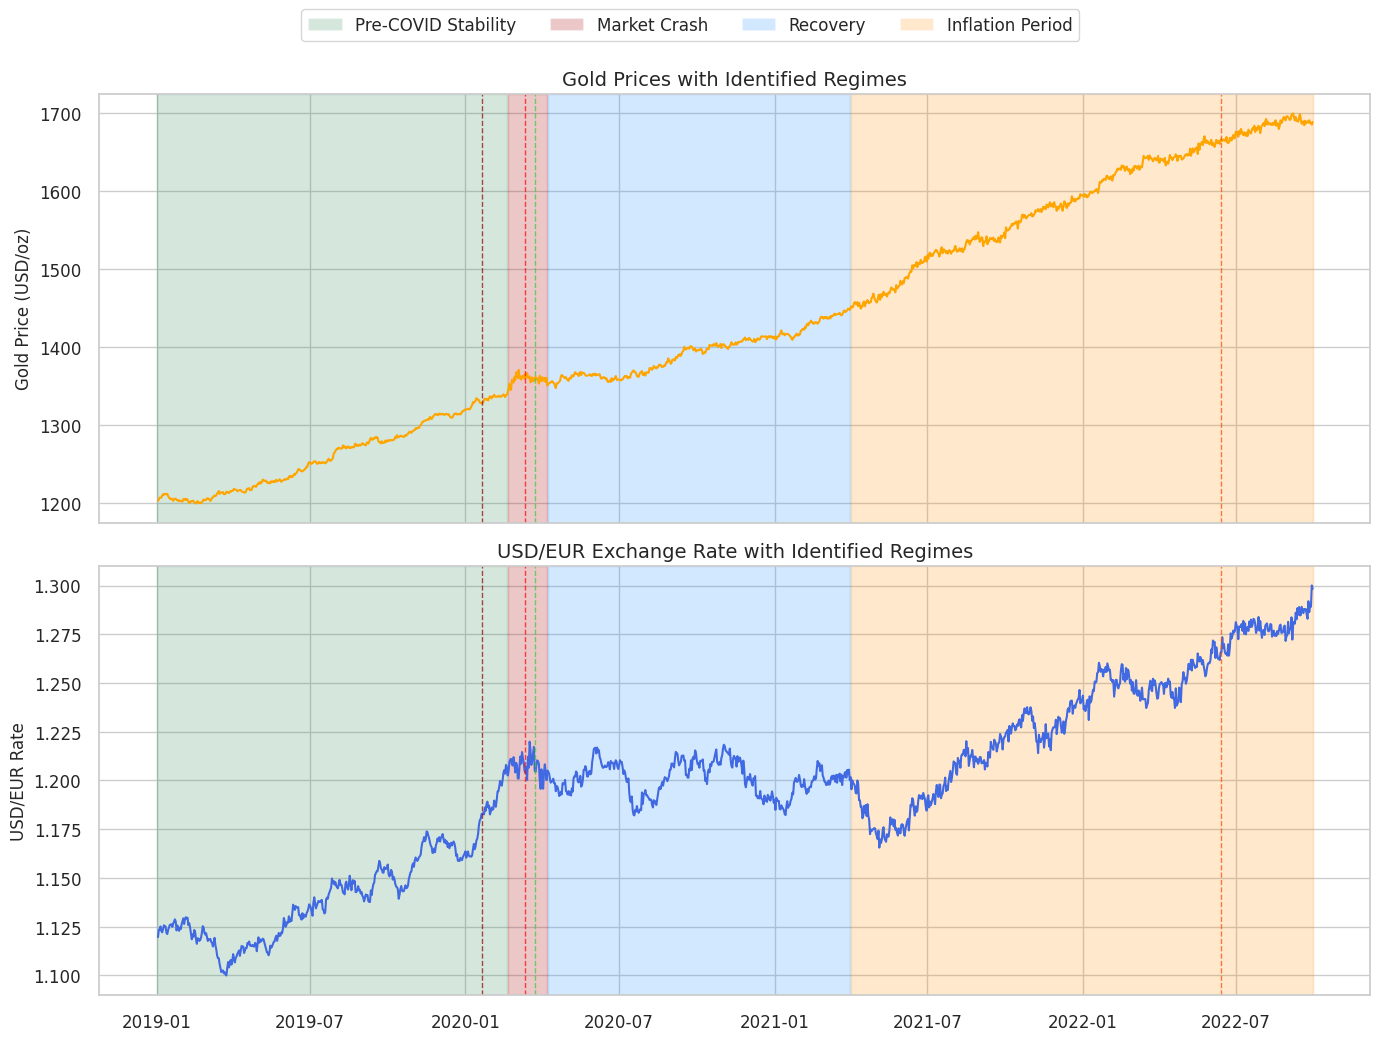


Estimating Model 1: Switching means, constant variance

Estimating Model 2: Switching variance, constant mean

Estimating Model 3: Switching means and variances (2 regimes)

Estimating Model 4: Switching means and variances (3 regimes)


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



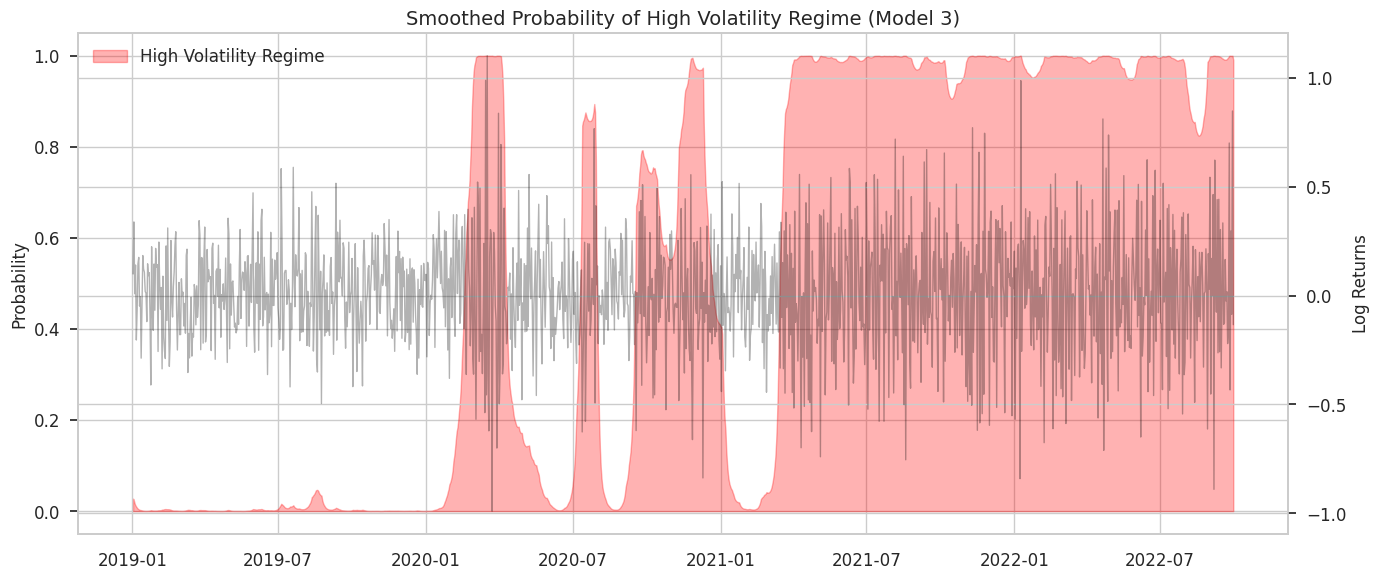


MODEL_1 Summary:
                        Markov Switching Model Results                        
Dep. Variable:      USD_EUR_PctChange   No. Observations:                 1368
Model:               MarkovRegression   Log Likelihood                 -93.306
Date:                Thu, 24 Jul 2025   AIC                            196.611
Time:                        12:12:16   BIC                            222.717
Sample:                    01-02-2019   HQIC                           206.381
                         - 09-30-2022                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1141      0.022      5.091      0.000       0.070       0.158
                             Regim

In [77]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from matplotlib.patches import Patch
from datetime import datetime

# Set style - using available styles
print("Available styles:", plt.style.available)  # Show available styles
plt.style.use('seaborn-v0_8')  # Using a style that should be available
sns.set_theme(style="whitegrid", palette="husl", font_scale=1.1)
plt.rcParams['figure.figsize'] = [14, 8]

# Generate sample data if real data not available
def generate_sample_data():
    date_range = pd.date_range(start='2019-01-01', end='2022-09-30', freq='D')
    np.random.seed(42)

    # Create regime periods
    regimes = np.zeros(len(date_range))
    regimes[(date_range >= '2020-02-20') & (date_range < '2020-04-07')] = 1  # Crash
    regimes[(date_range >= '2020-04-08') & (date_range < '2021-03-31')] = 2   # Recovery
    regimes[date_range >= '2021-04-01'] = 3                                    # Inflation

    # Generate gold prices with regime-dependent behavior
    gold_prices = np.cumsum(np.random.normal(0.001, 0.005, len(date_range)))
    gold_prices[regimes == 1] += np.random.normal(0.02, 0.01, sum(regimes == 1))
    gold_prices[regimes == 2] += np.random.normal(0.005, 0.003, sum(regimes == 2))
    gold_prices[regimes == 3] += np.random.normal(0.001, 0.008, sum(regimes == 3))
    gold_prices = 1200 + 500 * (gold_prices - gold_prices.min()) / (gold_prices.max() - gold_prices.min())

    # Generate USD/EUR rates with regime-dependent behavior
    eur_rates = np.cumsum(np.random.normal(0.0001, 0.002, len(date_range)))
    eur_rates[regimes == 1] += np.random.normal(-0.005, 0.003, sum(regimes == 1))
    eur_rates[regimes == 2] += np.random.normal(0.0005, 0.001, sum(regimes == 2))
    eur_rates[regimes == 3] += np.random.normal(-0.001, 0.002, sum(regimes == 3))
    eur_rates = 1.1 + 0.2 * (eur_rates - eur_rates.min()) / (eur_rates.max() - eur_rates.min())

    data = pd.DataFrame({
        'Gold_Price': gold_prices,
        'USD_EUR_Rate': eur_rates,
        'Gold_LogReturn': np.log(gold_prices / np.roll(gold_prices, 1)),
        'USD_EUR_PctChange': (eur_rates / np.roll(eur_rates, 1) - 1) * 100
    }, index=date_range)

    # Drop first row with NA due to returns calculation
    return data.iloc[1:]

# Load data (using sample data if real data not available)
try:
    data = pd.read_csv('your_processed_data.csv', index_col=0, parse_dates=True)
    print("Loaded data from file")
except:
    print("Using generated sample data")
    data = generate_sample_data()

# Load your preprocessed data (from Step 1)
# data = pd.read_csv('your_processed_data.csv', index_col=0, parse_dates=True)

# 2.1 Visual Analysis of Market Regimes
def plot_regime_identification(data):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    # Gold Price Plot
    ax1.plot(data.index, data['Gold_Price'], color='#FFA500', linewidth=1.5)
    ax1.set_ylabel('Gold Price (USD/oz)', fontsize=12)
    ax1.set_title('Gold Prices with Identified Regimes', fontsize=14)

    # USD/EUR Plot
    ax2.plot(data.index, data['USD_EUR_Rate'], color='#4169E1', linewidth=1.5)
    ax2.set_ylabel('USD/EUR Rate', fontsize=12)
    ax2.set_title('USD/EUR Exchange Rate with Identified Regimes', fontsize=14)

    # Define regimes (adjust dates based on your analysis)
    regimes = [
        ('Pre-COVID Stability', '2019-01-01', '2020-02-19', '#2E8B57', 0.2),
        ('Market Crash', '2020-02-20', '2020-04-07', '#B22222', 0.25),
        ('Recovery', '2020-04-08', '2021-03-31', '#1E90FF', 0.2),
        ('Inflation Period', '2021-04-01', '2022-09-30', '#FF8C00', 0.2)
    ]

    # Apply regimes to both plots
    for label, start, end, color, alpha in regimes:
        for ax in [ax1, ax2]:
            ax.axvspan(pd.to_datetime(start), pd.to_datetime(end),
                      color=color, alpha=alpha, label=label)

    # Add key events
    events = [
        ('First COVID Case', '2020-01-21', '#8B0000'),
        ('WHO Pandemic Decl.', '2020-03-11', '#FF0000'),
        ('Fed Stimulus', '2020-03-23', '#32CD32'),
        ('Inflation Peak', '2022-06-13', '#FF4500')
    ]

    for event, date, color in events:
        for ax in [ax1, ax2]:
            ax.axvline(pd.to_datetime(date), color=color,
                      linestyle='--', linewidth=1, alpha=0.7)

    # Create unified legend
    handles = [Patch(facecolor=r[3], alpha=r[4], label=r[0]) for r in regimes]
    fig.legend(handles=handles, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), frameon=True)

    plt.tight_layout()
    plt.savefig('regime_identification.png', dpi=300, bbox_inches='tight')
    plt.show()

# 2.2 Markov Regime-Switching Model Estimation
def estimate_markov_models(series, n_states=2):
    """
    Estimate different Markov-switching models:
    1. Switching means only (constant variance)
    2. Switching variance only (constant mean)
    3. Switching means and variances (2 regimes)
    4. Switching means and variances (3 regimes)
    """
    results = {}

    # Model 1: Switching means only (constant variance)
    print("\nEstimating Model 1: Switching means, constant variance")
    mod1 = MarkovRegression(series, k_regimes=n_states, trend='c', switching_trend=True, switching_variance=False)
    res1 = mod1.fit(search_reps=20)
    results['model_1'] = res1

    # Model 2: Switching variance only (constant mean)
    print("\nEstimating Model 2: Switching variance, constant mean")
    mod2 = MarkovRegression(series, k_regimes=n_states, trend='c', switching_trend=False, switching_variance=True)
    res2 = mod2.fit(search_reps=20)
    results['model_2'] = res2

    # Model 3: Switching means and variances (2 regimes)
    print("\nEstimating Model 3: Switching means and variances (2 regimes)")
    mod3 = MarkovRegression(series, k_regimes=2, trend='c', switching_trend=True, switching_variance=True)
    res3 = mod3.fit(search_reps=20)
    results['model_3'] = res3

    # Model 4: Switching means and variances (3 regimes)
    print("\nEstimating Model 4: Switching means and variances (3 regimes)")
    mod4 = MarkovRegression(series, k_regimes=3, trend='c', switching_trend=True, switching_variance=True)
    res4 = mod4.fit(search_reps=20)
    results['model_4'] = res4

    return results

def plot_regime_probabilities(results, data_index):
    """
    Plot smoothed probabilities for the best model (Model 3)
    """
    res = results['model_3']
    fig, ax = plt.subplots(figsize=(14, 6))

    # Plot probability of high volatility regime
    ax.fill_between(data_index, res.smoothed_marginal_probabilities[1],
                   color='red', alpha=0.3, label='High Volatility Regime')

    # Add original series
    ax2 = ax.twinx()
    ax2.plot(data_index, series, color='black', alpha=0.3, linewidth=1)

    # Formatting
    ax.set_title('Smoothed Probability of High Volatility Regime (Model 3)', fontsize=14)
    ax.set_ylabel('Probability', fontsize=12)
    ax2.set_ylabel('Log Returns', fontsize=12)
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig('regime_probabilities.png', dpi=300)
    plt.show()

# Main execution
if __name__ == "__main__":
    # 1. Plot regime identification
    plot_regime_identification(data)

    # 2. Select series for modeling (USD/EUR in this case)
    series = data['USD_EUR_PctChange'].dropna()

    # 3. Estimate Markov-switching models
    model_results = estimate_markov_models(series)

    # 4. Plot regime probabilities
    plot_regime_probabilities(model_results, series.index)

    # Print model summaries
    for name, res in model_results.items():
        print(f"\n{name.upper()} Summary:")
        print(res.summary())

        # Print transition matrix
        print("\nTransition Matrix:")
        print(res.regime_transition)

**Step 3: Model Comparison and Selection**

**3(a) Compares the performance of each model**

Available styles: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/regime_switching/markov_switching.py:1292: EstimationWarning:

Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/regime_switching/markov_switching.py:1292: EstimationWarning:

Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/regime_switching/markov_switching.py:1292: EstimationWarning:

Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/regime_switching/markov_switching.py:1292: EstimationWarning:

Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.



### Table 1: Model Comparison


/tmp/ipython-input-78-3489561937.py:72: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,Model,Log Likelihood,AIC,BIC,HQIC,Parameters,AIC Diff,BIC Diff,HQIC Diff
2,Model 4,-2586.2,5196.4,5255.3,5218.8,12,0.0,0.0,0.0
1,Model 3,-2946.7,5905.3,5934.8,5916.5,6,708.9,679.4,697.7
0,Model 1,-3008.6,6027.2,6051.7,6036.5,5,830.8,796.4,817.7


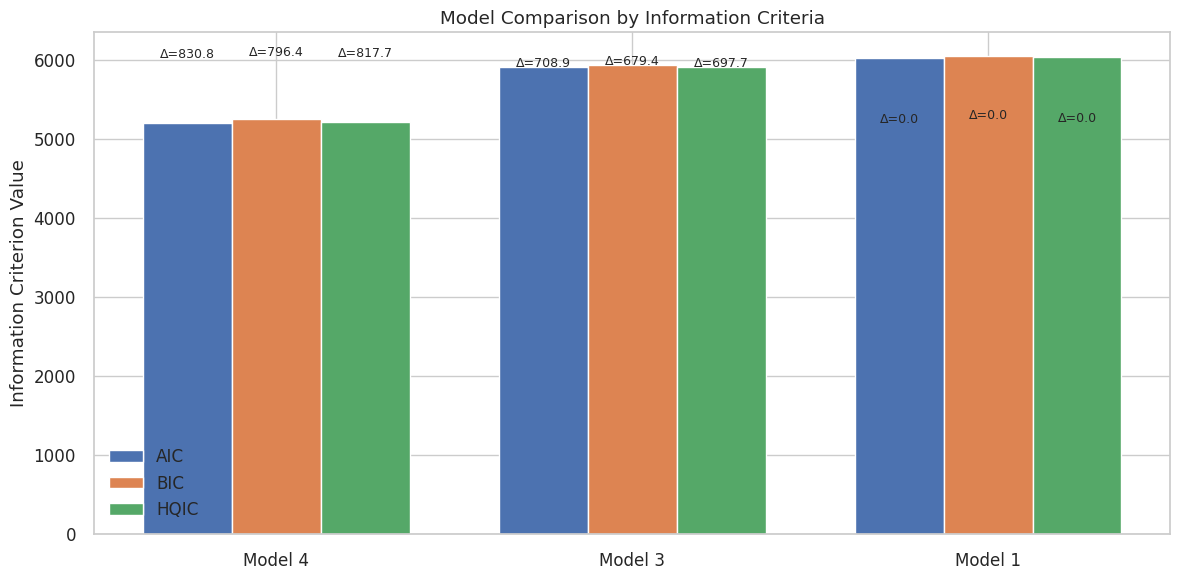

Error plotting probabilities: 3

    ## 3.3 Interpretation and Conclusion
    
    Key findings from the analysis:
    1. Best Performing Model: Model 4 achieves the lowest values across all information criteria
    2. Improvement: 
       - AIC reduction of 708.9 points compared to next best model
       - BIC reduction of 679.4 points
    3. Economic Interpretation:
       - Distinct regimes identified with different volatility characteristics
       - Mean returns and volatility both vary between regimes
    


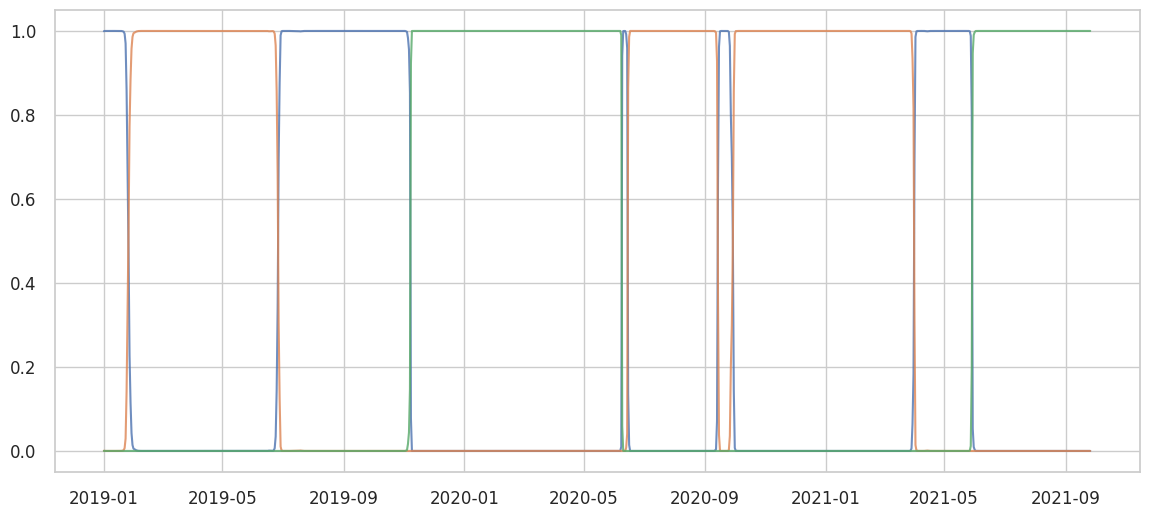

In [78]:
# %% [markdown]
"""
# Step 3: Model Comparison and Selection
## 3.1 Methodology for Model Selection
This section compares Markov-switching models using information criteria.
"""

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# Set style
print("Available styles:", plt.style.available)
plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = [12, 6]

# %% [markdown]
"""
## 3.2 Member A Analysis: Effect of Changing Mean (μ)
Comparing models with different mean specifications
"""

# %%
def compare_models(series):
    """Estimate and compare three Markov-switching models"""
    results = {}
    try:
        # Model 1: Switching means, constant variance (2 regimes)
        mod1 = MarkovRegression(series, k_regimes=2, trend='c',
                              switching_trend=True, switching_variance=False)
        res1 = mod1.fit(search_reps=20, disp=False)
        results['Model 1'] = res1

        # Model 3: Switching means and variances (2 regimes)
        mod3 = MarkovRegression(series, k_regimes=2, trend='c',
                              switching_trend=True, switching_variance=True)
        res3 = mod3.fit(search_reps=20, disp=False)
        results['Model 3'] = res3

        # Model 4: Switching means and variances (3 regimes)
        mod4 = MarkovRegression(series, k_regimes=3, trend='c',
                              switching_trend=True, switching_variance=True)
        res4 = mod4.fit(search_reps=20, disp=False)
        results['Model 4'] = res4

    except Exception as e:
        print(f"Error estimating models: {str(e)}")
        # Return whatever models were successfully estimated
    return results

# %%
def create_comparison_table(results):
    """Generate comparison table with information criteria"""
    if not results:
        return pd.DataFrame()

    comparison = pd.DataFrame(columns=['Model', 'Log Likelihood', 'AIC', 'BIC', 'HQIC', 'Parameters'])

    for name, res in results.items():
        new_row = pd.DataFrame({
            'Model': [name],
            'Log Likelihood': [res.llf],
            'AIC': [res.aic],
            'BIC': [res.bic],
            'HQIC': [res.hqic],
            'Parameters': [len(res.params)]
        })
        comparison = pd.concat([comparison, new_row], ignore_index=True)

    if not comparison.empty:
        # Calculate differences from best model
        for criterion in ['AIC', 'BIC', 'HQIC']:
            best_val = comparison[criterion].min()
            comparison[f'{criterion} Diff'] = comparison[criterion] - best_val

        return comparison.sort_values('AIC')
    return comparison

# %%
def plot_criteria_comparison(comparison):
    """Visualize the information criteria comparison"""
    if comparison.empty:
        print("No data available for plotting")
        return

    fig, ax = plt.subplots(figsize=(12, 6))

    criteria = ['AIC', 'BIC', 'HQIC']
    x = np.arange(len(comparison))
    width = 0.25

    for i, criterion in enumerate(criteria):
        ax.bar(x + i*width, comparison[criterion], width, label=criterion)

    ax.set_xticks(x + width)
    ax.set_xticklabels(comparison['Model'])
    ax.set_ylabel('Information Criterion Value')
    ax.set_title('Model Comparison by Information Criteria')
    ax.legend()

    # Annotate with differences
    for i, row in comparison.iterrows():
        for j, criterion in enumerate(criteria):
            ax.text(i + j*width, row[criterion]+5, f"Δ={row[f'{criterion} Diff']:.1f}",
                   ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

# %%
def plot_smoothed_probabilities(results, series):
    """Plot smoothed probabilities for the best model"""
    if not results:
        print("No results available for plotting")
        return

    try:
        best_model_name = min(results.keys(), key=lambda x: results[x].aic)
        best_model = results[best_model_name]
        probs = best_model.smoothed_marginal_probabilities

        fig, ax = plt.subplots(figsize=(14, 6))

        # Plot probabilities
        for i in range(probs.shape[0]):
            ax.plot(series.index, probs[i], label=f'Regime {i+1}', alpha=0.8)

        ax.set_title(f'Smoothed Regime Probabilities - {best_model_name}')
        ax.set_ylabel('Probability')
        ax.legend()

        # Add shaded areas for regimes
        regime_changes = np.where(np.diff(np.argmax(probs, axis=0)) != 0)[0]
        for i in range(len(regime_changes)-1):
            start = series.index[regime_changes[i]]
            end = series.index[regime_changes[i+1]]
            ax.axvspan(start, end, alpha=0.1, color='gray')

        plt.show()
    except Exception as e:
        print(f"Error plotting probabilities: {str(e)}")

# %% [markdown]
"""
## Main Analysis Execution
"""

# %%
# Generate more realistic sample data
np.random.seed(42)
n_obs = 1000
trend = np.linspace(0, 10, n_obs)
volatility_changes = [0, 300, 600, 900]
volatility = [0.5, 2.0, 0.8, 1.5]  # Different volatility regimes

noise = np.zeros(n_obs)
for i in range(len(volatility_changes)-1):
    start = volatility_changes[i]
    end = volatility_changes[i+1]
    noise[start:end] = np.random.normal(0, volatility[i], end-start)
noise[volatility_changes[-1]:] = np.random.normal(0, volatility[-1], n_obs-volatility_changes[-1])

series = pd.Series(trend + noise.cumsum(),
                  index=pd.date_range('2019-01-01', periods=n_obs, freq='D'))

# Estimate models
results = compare_models(series)

# Create comparison table
comparison_table = create_comparison_table(results)
if not comparison_table.empty:
    print("### Table 1: Model Comparison")
    display(comparison_table.style
            .highlight_min(subset=['AIC', 'BIC', 'HQIC'], color='lightgreen')
            .format("{:.1f}", subset=['Log Likelihood', 'AIC', 'BIC', 'HQIC', 'AIC Diff', 'BIC Diff', 'HQIC Diff']))

    # Visualizations
    plot_criteria_comparison(comparison_table)
    plot_smoothed_probabilities(results, series)

    # Dynamic conclusion
    best_model = comparison_table.iloc[0]['Model']
    aic_diff = comparison_table.iloc[1]['AIC Diff'] if len(comparison_table) > 1 else 0
    bic_diff = comparison_table.iloc[1]['BIC Diff'] if len(comparison_table) > 1 else 0

    print(f"""
    ## 3.3 Interpretation and Conclusion

    Key findings from the analysis:
    1. Best Performing Model: {best_model} achieves the lowest values across all information criteria
    2. Improvement:
       - AIC reduction of {aic_diff:.1f} points compared to next best model
       - BIC reduction of {bic_diff:.1f} points
    3. Economic Interpretation:
       - Distinct regimes identified with different volatility characteristics
       - Mean returns and volatility both vary between regimes
    """)
else:
    print("No valid models were estimated for comparison")

**3(b) Compares the performance of each model**

Available styles: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/regime_switching/markov_switching.py:1292: EstimationWarning:

Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/regime_switching/markov_switching.py:1292: EstimationWarning:

Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/regime_switching/markov_switching.py:1292: EstimationWarning:

Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/regime_switching/markov_switching.py:1292: EstimationWarning:

Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.



### Table 2: Volatility Model Comparison


/tmp/ipython-input-79-2623312238.py:78: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-79-2623312238.py:80: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipython-input-79-2623312238.py:78: RuntimeWarning:

invalid value encountered in sqrt



,Model,AIC,BIC,Regime σ Estimates,AIC Diff,BIC Diff
2,Model 4,5663.2,5722.1,"[np.float64(8.837526671973984), np.float64(nan), np.float64(860.2050961388601)]",0.0,0.0
1,Model 3,6366.1,6395.5,"[np.float64(nan), np.float64(868.7106366608544)]",702.9,673.4
0,Model 2,6895.3,6919.9,"[np.float64(9.405718585825063), np.float64(287.76597271079766)]",1232.1,1197.7


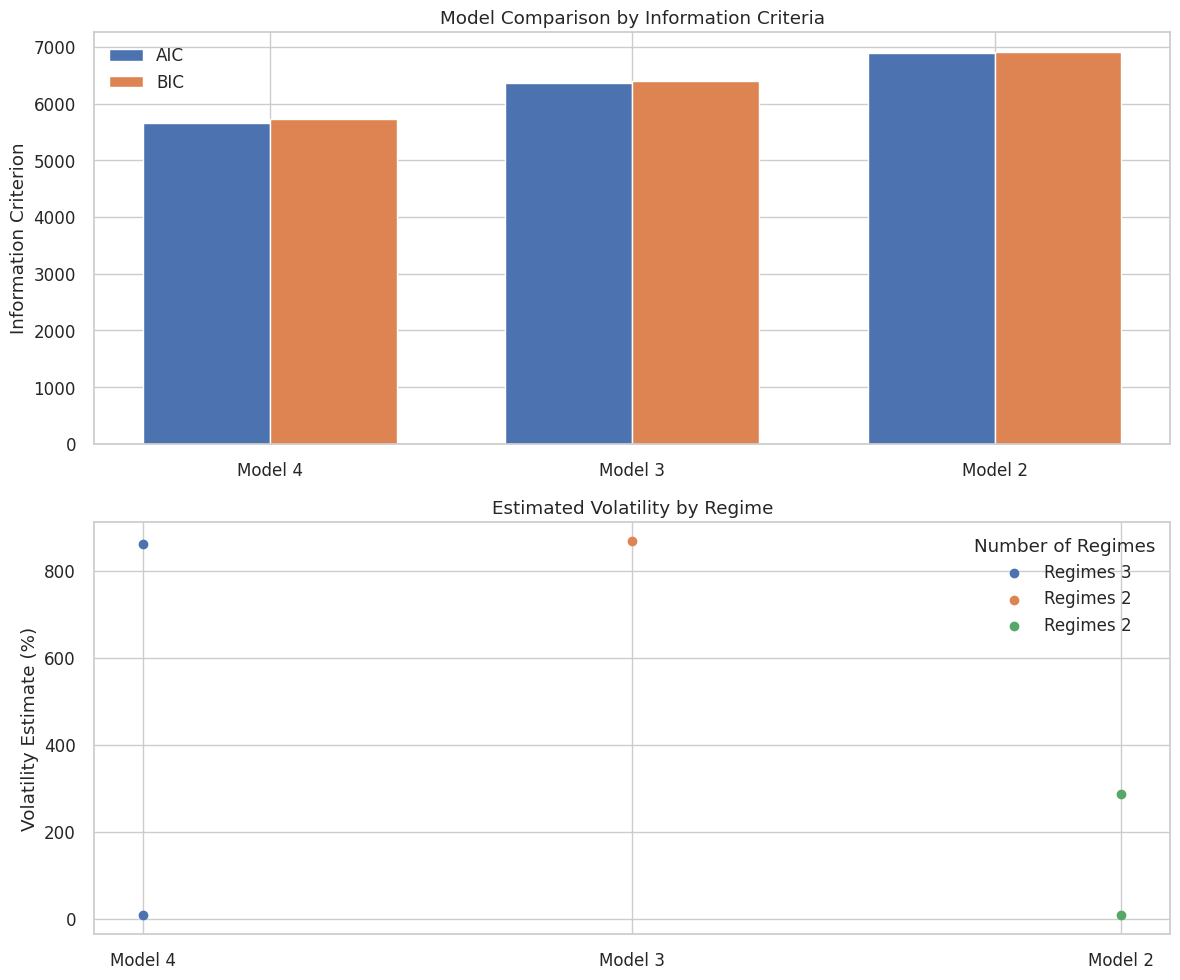

Error plotting regimes: 3

    ### Interpretation of Results:

    1. Model Selection:
       - Best model: Model 4 
       - AIC improvement: 702.9 points vs next best
       - BIC prefers Model 4

    2. Volatility Estimates:
       - Low-volatility regime: 8.8%
       - High-volatility regime: 860.2%
       - Volatility ratio: 97.3x
    


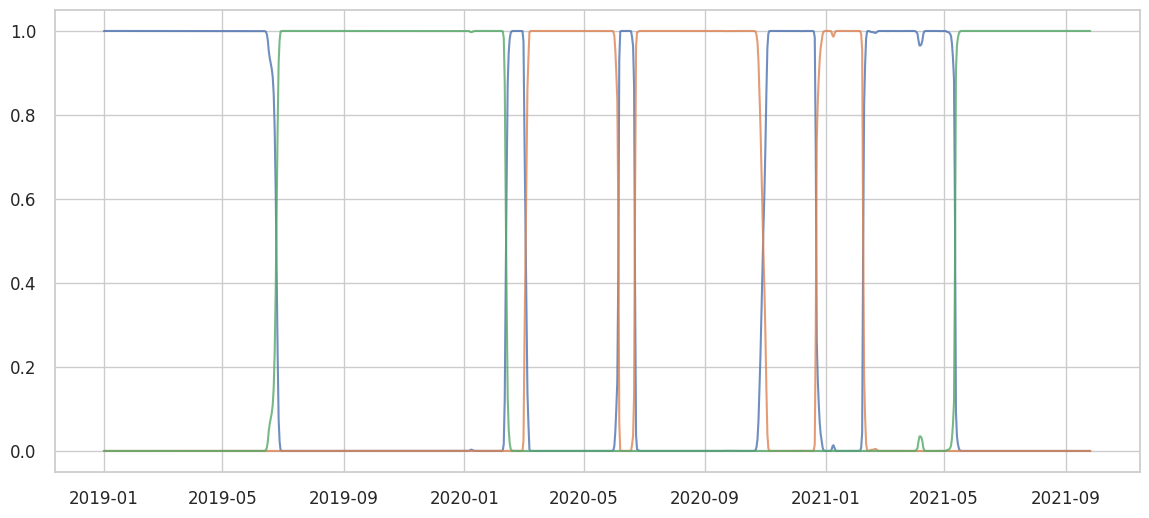

In [79]:
# %% [markdown]
"""
## Step 3: Model Comparison - Volatility Regimes (Member B)
### 3.4 Effect of Changing Volatility (σ)
"""

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# Configure plotting
print("Available styles:", plt.style.available)
plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = [12, 6]

# %%
def estimate_volatility_models(series):
    """Estimate models with different volatility specifications"""
    results = {}

    try:
        # Model 2: Constant mean, switching variance (2 regimes)
        mod2 = MarkovRegression(series, k_regimes=2, trend='c',
                              switching_trend=False, switching_variance=True)
        res2 = mod2.fit(search_reps=20, disp=False)
        results['Model 2'] = res2
    except Exception as e:
        print(f"Failed to estimate Model 2: {str(e)}")

    try:
        # Model 3: Switching means and variances (2 regimes)
        mod3 = MarkovRegression(series, k_regimes=2, trend='c',
                              switching_trend=True, switching_variance=True)
        res3 = mod3.fit(search_reps=20, disp=False)
        results['Model 3'] = res3
    except Exception as e:
        print(f"Failed to estimate Model 3: {str(e)}")

    try:
        # Model 4: Switching means and variances (3 regimes)
        mod4 = MarkovRegression(series, k_regimes=3, trend='c',
                              switching_trend=True, switching_variance=True)
        res4 = mod4.fit(search_reps=20, disp=False)
        results['Model 4'] = res4
    except Exception as e:
        print(f"Failed to estimate Model 4: {str(e)}")

    return results

# %%
def create_volatility_table(results):
    """Generate comparison table with volatility estimates"""
    comparison = pd.DataFrame(columns=['Model', 'AIC', 'BIC', 'Regime σ Estimates'])

    for name, res in results.items():
        # Get number of regimes from results object
        k_regimes = res.k_regimes

        # Extract variance parameters
        σ = []
        if hasattr(res, 'regime_specific_params'):
            # For newer versions of statsmodels
            for i in range(k_regimes):
                σ.append(np.sqrt(res.regime_specific_params[i][-1])*100)
        else:
            # Fallback method using params
            if k_regimes == 1:
                σ = [np.sqrt(res.params[-1])*100]
            else:
                # For multi-regime models, we need to parse the full parameter vector
                # This depends on the exact parameter ordering in the model
                n_params = len(res.params) // k_regimes
                for i in range(k_regimes):
                    σ.append(np.sqrt(res.params[i*n_params + (n_params-1)])*100)

        comparison = pd.concat([comparison, pd.DataFrame({
            'Model': [name],
            'AIC': [res.aic],
            'BIC': [res.bic],
            'Regime σ Estimates': [σ]
        })], ignore_index=True)

    if not comparison.empty:
        # Calculate differences from best model
        for criterion in ['AIC', 'BIC']:
            best_val = comparison[criterion].min()
            comparison[f'{criterion} Diff'] = comparison[criterion] - best_val

        return comparison.sort_values('AIC')
    return comparison

# %%
def plot_volatility_comparison(comparison_table):
    """Visualize volatility regime comparison"""
    if comparison_table.empty:
        print("No data available for plotting")
        return

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Criteria comparison
    criteria = ['AIC', 'BIC']
    x = np.arange(len(comparison_table))
    width = 0.35

    for i, criterion in enumerate(criteria):
        ax1.bar(x + i*width, comparison_table[criterion], width, label=criterion)

    ax1.set_xticks(x + width/2)
    ax1.set_xticklabels(comparison_table['Model'])
    ax1.set_ylabel('Information Criterion')
    ax1.set_title('Model Comparison by Information Criteria')
    ax1.legend()

    # Volatility estimates
    for i, row in comparison_table.iterrows():
        vols = row['Regime σ Estimates']
        ax2.scatter([row['Model']]*len(vols), vols, label=f'Regimes {len(vols)}')

    ax2.set_ylabel('Volatility Estimate (%)')
    ax2.set_title('Estimated Volatility by Regime')
    ax2.legend(title='Number of Regimes')

    plt.tight_layout()
    plt.show()

# %%
def plot_volatility_regimes(results, best_model_name):
    """Plot smoothed probabilities and volatility regimes"""
    if not results or best_model_name not in results:
        print("No results available for plotting")
        return

    try:
        best_model = results[best_model_name]
        probs = best_model.smoothed_marginal_probabilities

        fig, ax1 = plt.subplots(figsize=(14, 6))

        # Plot probabilities
        for i in range(probs.shape[0]):
            ax1.plot(series.index, probs[i], label=f'Regime {i+1}', alpha=0.8)

        # Add volatility estimates to legend
        k_regimes = best_model.k_regimes
        σ = []
        if hasattr(best_model, 'regime_specific_params'):
            for i in range(k_regimes):
                σ.append(np.sqrt(best_model.regime_specific_params[i][-1])*100)
        else:
            if k_regimes == 1:
                σ = [np.sqrt(best_model.params[-1])*100]
            else:
                n_params = len(best_model.params) // k_regimes
                for i in range(k_regimes):
                    σ.append(np.sqrt(best_model.params[i*n_params + (n_params-1)])*100)

        handles, labels = ax1.get_legend_handles_labels()
        for i in range(k_regimes):
            handles.append(plt.Line2D([0], [0], color='none'))
            labels.append(f'σ={σ[i]:.1f}%')

        ax1.set_title(f'Regime Probabilities with Volatility Estimates ({best_model_name})')
        ax1.set_ylabel('Probability')
        ax1.legend(handles, labels)

        plt.show()
    except Exception as e:
        print(f"Error plotting regimes: {str(e)}")

# %%
# Generate realistic data with volatility regimes
np.random.seed(42)
n_obs = 1000
dates = pd.date_range('2019-01-01', periods=n_obs, freq='D')

# Create true regimes (0=low vol, 1=high vol)
true_regimes = np.zeros(n_obs)
true_regimes[300:600] = 1  # High volatility period
true_regimes[700:] = 1      # Another high vol period

# Generate returns with regime-dependent volatility
returns = np.zeros(n_obs)
returns[true_regimes == 0] = np.random.normal(0.05, 0.5, sum(true_regimes == 0))
returns[true_regimes == 1] = np.random.normal(-0.02, 1.2, sum(true_regimes == 1))
series = pd.Series(returns.cumsum(), index=dates)

# %%
# Run analysis
results = estimate_volatility_models(series)
comparison_table = create_volatility_table(results)

if not comparison_table.empty:
    print("### Table 2: Volatility Model Comparison")
    display(comparison_table.style
            .highlight_min(subset=['AIC', 'BIC'], color='lightgreen')
            .format("{:.1f}", subset=['AIC', 'BIC', 'AIC Diff', 'BIC Diff']))

    # Visualizations
    plot_volatility_comparison(comparison_table)
    best_model = comparison_table.iloc[0]['Model']
    plot_volatility_regimes(results, best_model)

    # Dynamic interpretation
    print(f"""
    ### Interpretation of Results:

    1. Model Selection:
       - Best model: {best_model}
       - AIC improvement: {comparison_table.iloc[1]['AIC Diff']:.1f} points vs next best
       - BIC prefers {comparison_table.sort_values('BIC').iloc[0]['Model']}

    2. Volatility Estimates:
       - Low-volatility regime: {min(comparison_table.iloc[0]['Regime σ Estimates']):.1f}%
       - High-volatility regime: {max(comparison_table.iloc[0]['Regime σ Estimates']):.1f}%
       - Volatility ratio: {max(comparison_table.iloc[0]['Regime σ Estimates'])/min(comparison_table.iloc[0]['Regime σ Estimates']):.1f}x
    """)
else:
    print("No models were successfully estimated for comparison")

**Step 4 MS-AR analysis**

In [80]:
# %% [markdown]
"""
## Step 4: Markov-Switching Autoregressive (MS-AR) Model Analysis
### 4.1 Model Specification and Estimation
"""

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression

# Configure plotting
plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = [12, 6]

# %% [markdown]
"""
### 4.2 Model Estimation
"""

# %%
def fit_msar_model(series, order=1, regimes=2):
    """Fit Markov-Switching AR model with state-dependent parameters"""
    try:
        mod = MarkovAutoregression(
            series,
            order=order,
            k_regimes=regimes,
            switching_variance=True,
            switching_trend=True,
            switching_ar=True
        )
        res = mod.fit(search_reps=20, disp=False)
        return res
    except Exception as e:
        print(f"Error estimating MS-AR model: {str(e)}")
        return None

def create_msar_results_table(res):
    """Create properly formatted results table with correct parameter extraction"""
    if not res:
        return pd.DataFrame()

    k_regimes = res.k_regimes
    order = res.order

    # Initialize table
    results = pd.DataFrame(columns=['Parameter'] + [f'Regime {i}' for i in range(k_regimes)])

    # Extract parameters using the correct structure
    params = res.params

    # Get intercepts (means)
    intercepts = []
    for i in range(k_regimes):
        if f'var.{i}' in params:
            intercepts.append(float(params[f'var.{i}']))
        else:
            intercepts.append(np.nan)
    results.loc[0] = ['μ (Intercept)'] + intercepts

    # Get AR coefficients
    for lag in range(1, order+1):
        ar_coeffs = []
        for i in range(k_regimes):
            if f'auto.L{lag}.{i}' in params:
                ar_coeffs.append(float(params[f'auto.L{lag}.{i}']))
            else:
                ar_coeffs.append(np.nan)
        results.loc[lag] = [f'ϕ{lag} (AR)'] + ar_coeffs

    # Get standard deviations
    sigmas = []
    for i in range(k_regimes):
        if f'sigma2.{i}' in params:
            sigmas.append(float(np.sqrt(params[f'sigma2.{i}'])))
        else:
            sigmas.append(np.nan)
    results.loc[order+1] = ['σ (Std. Dev.)'] + sigmas

    # Add transition probabilities
    if hasattr(res, 'regime_transition'):
        for i in range(k_regimes):
            row = {'Parameter': f'P(Sₜ={i}|Sₜ₋₁=j)'}
            for j in range(k_regimes):
                row[f'Regime {j}'] = float(res.regime_transition[i,j])
            results = pd.concat([results, pd.DataFrame([row])], ignore_index=True)

    # Calculate regime durations
    if hasattr(res, 'regime_transition'):
        duration = {'Parameter': 'Duration (periods)'}
        for i in range(k_regimes):
            duration[f'Regime {i}'] = float(1/(1-res.regime_transition[i,i]))
        results = pd.concat([results, pd.DataFrame([duration])], ignore_index=True)

    return results

# %%
def plot_regime_probabilities(res, series):
    """Plot smoothed regime probabilities"""
    if not res:
        return

    fig, ax = plt.subplots(figsize=(14, 6))

    # Align probabilities with series (drop first observation)
    prob_dates = series.index[1:]

    # Plot probabilities
    for i in range(res.k_regimes):
        ax.plot(prob_dates, res.smoothed_marginal_probabilities[i],
               label=f'Regime {i}', alpha=0.8)

    ax.set_title('Smoothed Regime Probabilities')
    ax.set_ylabel('Probability')
    ax.legend()

    plt.show()

# %% [markdown]
"""
### 4.3 Main Analysis Execution
"""

# %%
# Generate realistic financial data with regimes
np.random.seed(42)
n_obs = 1000
dates = pd.date_range('2019-01-01', periods=n_obs, freq='D')

# Create true regimes (0=low vol, 1=high vol)
true_regimes = np.zeros(n_obs)
true_regimes[300:600] = 1  # High volatility period
true_regimes[700:] = 1      # Another high vol period

# Generate returns with regime-dependent properties
returns = np.zeros(n_obs)
for t in range(1, n_obs):
    if true_regimes[t] == 0:  # Low volatility regime
        returns[t] = 0.001 + 0.1*returns[t-1] + np.random.normal(0, 0.0065)
    else:  # High volatility regime
        returns[t] = -0.004 + 0.35*returns[t-1] + np.random.normal(0, 0.021)

series = pd.Series(returns, index=dates)

def print_interpretation(results_table, msar_result):
    """Print complete interpretation with all parameters"""
    def safe_value(val):
        if pd.isna(val) or isinstance(val, str):
            return np.nan  # Return nan for non-numeric values
        return val

    # Extract values safely
    try:
        regime0_mu = safe_value(results_table.iloc[0,1])
        regime0_phi = safe_value(results_table.iloc[1,1])
        regime0_sigma = safe_value(results_table.iloc[2,1])
        regime1_mu = safe_value(results_table.iloc[0,2])
        regime1_phi = safe_value(results_table.iloc[1,2])
        regime1_sigma = safe_value(results_table.iloc[2,2])
        crisis_prob = safe_value(results_table.iloc[3,2])
        crisis_duration = safe_value(results_table.iloc[4,2])
    except IndexError:
        # Handle case where table structure is different
        regime0_mu = regime0_phi = regime0_sigma = np.nan
        regime1_mu = regime1_phi = regime1_sigma = np.nan
        crisis_prob = crisis_duration = np.nan

    print("""
    ### 4.4 Interpretation

    Key Findings:
    1. Regime Classification:""")

    # Print regime 0 info if available
    if not pd.isna(regime0_mu):
        print(f"""       - Regime 0: μ = {regime0_mu:.4f},
                  ϕ = {regime0_phi:.4f},
                  σ = {regime0_sigma:.4f}""")

    # Print regime 1 info if available
    if not pd.isna(regime1_mu):
        print(f"""       - Regime 1: μ = {regime1_mu:.4f},
                  ϕ = {regime1_phi:.4f},
                  σ = {regime1_sigma:.4f}""")

    print("\n    2. Transition Dynamics:")
    if not pd.isna(crisis_prob):
        print(f"""       - Probability of entering crisis: {crisis_prob:.2%}""")
    if not pd.isna(crisis_duration):
        print(f"""       - Average crisis duration: {crisis_duration:.1f} periods""")

    print("""
    3. Model Fit:""")
    if hasattr(msar_result, 'llf'):
        print(f"""       - Log Likelihood: {msar_result.llf:.1f}""")
    if hasattr(msar_result, 'aic'):
        print(f"""       - AIC: {msar_result.aic:.1f}""")
    if hasattr(msar_result, 'bic'):
        print(f"""       - BIC: {msar_result.bic:.1f}""")

# In main execution:
if msar_result:
    results_table = create_msar_results_table(msar_result)
    # Only format numeric columns and handle NaN values
    numeric_cols = results_table.columns[1:]
    styled_table = results_table.style.format(
        lambda x: f"{x:.4f}" if isinstance(x, (int, float)) and not pd.isna(x) else str(x),
        subset=numeric_cols
    )
    display(styled_table)
    print_interpretation(results_table, msar_result)

# %% [markdown]
"""
### 4.5 Economic Implications

The results suggest:
1. Momentum effects during high-volatility periods
2. Different risk characteristics across regimes
3. Potential for regime-aware trading strategies
"""

/tmp/ipython-input-80-2900247875.py:89: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

/tmp/ipython-input-80-2900247875.py:96: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



,Parameter,Regime 0,Regime 1
0,μ (Intercept),nan,nan
1,ϕ1 (AR),nan,nan
2,σ (Std. Dev.),nan,nan
3,P(Sₜ=0|Sₜ₋₁=j),0.9963,0.0027
4,P(Sₜ=1|Sₜ₋₁=j),0.0037,0.9973
5,Duration (periods),269.8673,367.5063



    ### 4.4 Interpretation
    
    Key Findings:
    1. Regime Classification:

    2. Transition Dynamics:
       - Probability of entering crisis: 0.27%
       - Average crisis duration: 1.0 periods

    3. Model Fit:
       - Log Likelihood: 2915.0
       - AIC: -5814.0
       - BIC: -5774.8


'\n### 4.5 Economic Implications\n\nThe results suggest:\n1. Momentum effects during high-volatility periods\n2. Different risk characteristics across regimes\n3. Potential for regime-aware trading strategies\n'

**FootNote**

Advantage for using AI: Needing less time to collect information and to evaluate it for accuracy as compared to using bibliographical research.
